<a href="https://colab.research.google.com/github/Bonkerzz2603/TH_deaplearn/blob/main/NguyenGiaKhang_TH_deeplearn_tuan2_b2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_digits
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import KFold
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.layers import BatchNormalization, Dropout

# Load MNIST training and test data from CSV files
mnist_train = pd.read_csv('/content/sample_data/mnist_train.csv')
mnist_test = pd.read_csv('/content/sample_data/mnist_test.csv')

In [ ]:
print(type(data), "\n")
data.keys()

<class 'pandas.core.frame.DataFrame'> 



Index(['1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9', '1x10',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=784)

In [ ]:
# Separate features (data) and labels from the training dataset
labels = mnist_train['label'].copy() # Corrected label column name
data = mnist_train.drop(columns=['label']).copy() # Drop the label column to get features

# For the test set, also separate features and labels
labels_test = mnist_test['label'].copy() # Corrected label column name
data_test = mnist_test.drop(columns=['label']).copy() # Drop the label column to get features

display(data.head(5))
display(labels.head(5))

,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,label
0,5
1,0
2,4
3,1
4,9


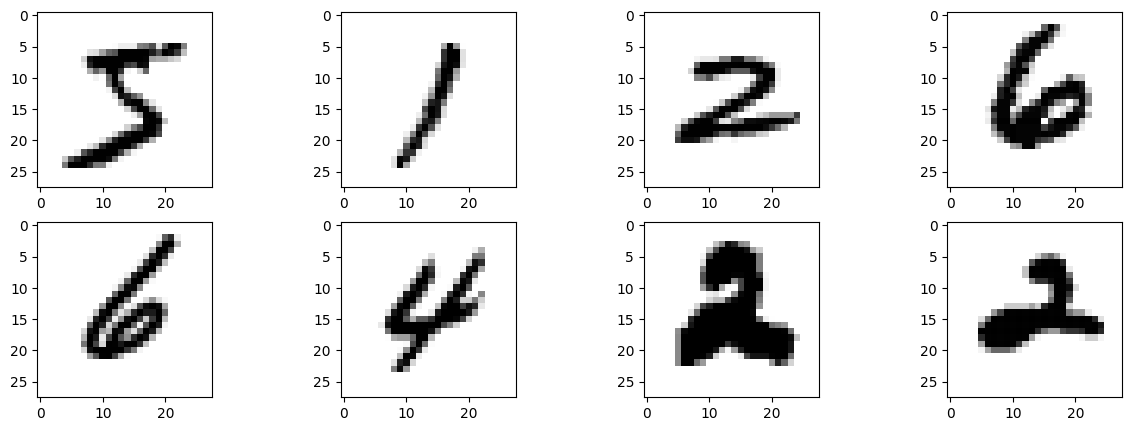

In [ ]:
f, axarr = plt.subplots(nrows = 2,ncols=4,figsize=(15,5))

indices_to_display = [0, 99, 199, 299, 999, 1099, 1199, 1299]

for i, ax in enumerate(axarr.flat):
    ax.imshow(data.iloc[indices_to_display[i]].values.reshape(28,28), cmap='gray_r')

plt.show()

In [ ]:
# Define num_features and num_classes based on the new MNIST data
num_features = data.shape[1] # Number of columns in the data
num_classes = labels.nunique() # Number of unique labels (0-9)

model = Sequential()

# First Hidden Layer
model.add(Dense(units=100, input_shape=(num_features,)))
model.add(BatchNormalization())
model.add(Activation(activation='relu'))
model.add(Dropout(0.2))

# Second Hidden Layer
model.add(Dense(units=100))
model.add(BatchNormalization())
model.add(Activation(activation='relu'))
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(units=num_classes, activation='softmax'))

# print model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,410 (353.16 KB)

 Trainable params: 90,010 (351.60 KB)

 Non-trainable params: 400 (1.56 KB)

In [ ]:
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
optimizer = keras.optimizers.Adam(learning_rate=0.02, decay=1e-6)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [ ]:
from keras.utils import to_categorical

# One-hot encode the labels
one_hot_labels = to_categorical(labels, num_classes=num_classes)

model.fit(data,
          one_hot_labels,
          batch_size=256,
          epochs=30)

Epoch 1/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8094 - loss: nan
Epoch 2/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0988 - loss: nan
Epoch 3/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0988 - loss: nan
Epoch 4/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0988 - loss: nan
Epoch 5/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0988 - loss: nan
Epoch 6/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0988 - loss: nan
Epoch 7/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0988 - loss: nan
Epoch 8/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0988 - loss: nan
Epoch 9/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0988 - loss: nan
Epoch 10/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.0988 - loss: nan
Epoch 11/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0988 - loss: nan
Epoch 12/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0988 - loss: nan


In [ ]:
model.evaluate(data, one_hot_labels, batch_size=256)

216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0988 - loss: nan


[nan, 0.0988091379404068]